In [11]:
pip install langgraph langsmith

Defaulting to user installation because normal site-packages is not writeable
  Using cached xxhash-3.5.0-cp312-cp312-win_amd64.whl.metadata (13 kB)
     ---------------------------------------- 0.0/44.4 kB ? eta -:--:--
     --------- ------------------------------ 10.2/44.4 kB ? eta -:--:--
     -------------------------------------- 44.4/44.4 kB 726.0 kB/s eta 0:00:00
  Using cached langchain_core-0.3.51-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/144.7 kB ? eta -:--:--
   ---------------------------------------  143.4/144.7 kB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 144.7/144.7 kB 2.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/42.0 kB ? eta -:--:--
   ---------------------------------------- 42.0/42.0 kB 2.1 MB/s eta 0:00:00
Using cached langchain_core-0.3.51-py3-none-any.whl (423 kB)
   ---------------------------------------- 0.0/47.2 kB ? eta -:--:--
   ---------------------------------------- 

In [12]:
pip install langchain langchain_groq langchain_community

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/126.7 kB ? eta -:--:--
   --- ------------------------------------ 10.2/126.7 kB ? eta -:--:--
   ------------ -------------------------- 41.0/126.7 kB 487.6 kB/s eta 0:00:01
   ---------------------------- ---------- 92.2/126.7 kB 744.7 kB/s eta 0:00:01
   -------------------------------------- 126.7/126.7 kB 677.0 kB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


#### For colab save and fetch the saved API Keys


In [1]:
# from google.colab import userdata
# grog_api_key = userdata.get('groq_api_key')

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()
groq_api_key = os.getenv('groq_api_key')
langsmith = os.getenv("LANGCHAIN_TRACING_V2")
course_length = os.getenv("LANGCHAIN_PROJECT")

In [3]:
from langchain_groq import ChatGroq

In [4]:
llm = ChatGroq(groq_api_key=groq_api_key, model_name="Gemma2-9b-It")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001DA5C124EC0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DA5C126120>, model_name='Gemma2-9b-It', model_kwargs={}, groq_api_key=SecretStr('**********'))

### Start building ChatBot using LangGraph

In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END # StateGraph helps in managing state  show flow of entire chatbot
from langgraph.graph.message import add_messages

In [6]:
class State(TypedDict):
  # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
  messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)


In [7]:
graph_builder

In [8]:
def chatbot(state:State):
  return {"messages":llm.invoke(state['messages'])}



In [9]:
graph_builder.add_node("chatbot",chatbot)

In [10]:
graph_builder

In [11]:
graph_builder.add_edge(START,"chatbot")
graph_builder.add_edge("chatbot",END)

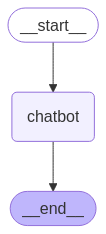

In [12]:
from IPython.display import Image, display
graph=graph_builder.compile()

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [ ]:
while True:
  user_input=input("User: ")
  if user_input.lower() in ["quit","q"]:
    print("Good Bye")
    break
  for event in graph.stream({'messages':("user",user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value["messages"].content)

dict_values([{'messages': AIMessage(content="Please provide me with a question or a topic you'd like to discuss! I'm here to help with:\n\n* **Answering questions:** I can provide information on a wide range of topics.\n* **Generating creative content:** I can write stories, poems, articles, and more.\n* **Summarizing text:** I can condense large amounts of text into shorter summaries.\n* **Translating languages:** I can translate text between many different languages.\n* **And much more!**\n\nWhat can I do for you today? 😊\n", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 116, 'prompt_tokens': 11, 'total_tokens': 127, 'completion_time': 0.210909091, 'prompt_time': 0.001982585, 'queue_time': 0.23158394399999999, 'total_time': 0.212891676}, 'model_name': 'Gemma2-9b-It', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'stop', 'logprobs': None}, id='run-74ef5067-e750-44c1-b416-af4b8bad7f19-0', usage_metadata={'input_tokens': 11, 'output_tokens': 116

In [ ]:
graph=graph_builder.compile()